<a href="https://colab.research.google.com/github/manhnt2115/TH_DeepLearning/blob/main/TH_DeepLearning_Tuan2(18_05).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

# load dataset
df = pd.read_csv('/content/sample_data/heart_disease_dataset_cleaned.csv', sep=';')

# xem dữ liệu
print(df.head())
print(df.info())

# kiểm tra missing value
print(df.isnull().sum())

# xử lý dữ liệu categorical
df['sex'] = df['sex'].map({'m':1,'f':0})
df['fbs'] = df['fbs'].map({'yes':1,'no':0})

# one hot encoding cho cp
df = pd.get_dummies(df, columns=['cp'])

# target
y = df['state']
X = df.drop('state', axis=1)

print(X.head())

    age sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0   m  tap     145.0  233.0  yes      2.0    150.0    0.0      2.3   
1  67.0   m  asp     160.0  286.0   no      2.0    108.0    1.0      1.5   
2  67.0   m  asp     120.0  229.0   no      2.0    129.0    1.0      2.6   
3  37.0   m  nap     130.0  250.0   no      0.0    187.0    0.0      3.5   
4  41.0   f  aap     130.0  204.0   no      2.0    172.0    0.0      1.4   

   slope   ca  thal  state  
0    3.0  0.0   6.0    0.0  
1    2.0  3.0   3.0    2.0  
2    2.0  2.0   7.0    1.0  
3    3.0  0.0   3.0    0.0  
4    1.0  0.0   3.0    0.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    object 
 2   cp        303 non-null    object 
 3   trestbps  303 non-null    float64
 4   chol      303 non-null   

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# train 70%, temp 30%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42)

# validation 15%, test 15%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)

print("Train:",X_train.shape)
print("Validation:",X_val.shape)
print("Test:",X_test.shape)

# scaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

Train: (212, 16)
Validation: (45, 16)
Test: (46, 16)


In [4]:
# chuyển sang numpy
X_train = np.array(X_train)
X_val = np.array(X_val)
y_train = np.array(y_train)
y_val = np.array(y_val)

# thêm bias
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_val = np.c_[np.ones(X_val.shape[0]), X_val]

# khởi tạo weight
w = np.zeros(X_train.shape[1])

# hyperparameter
lr = 0.01
epochs = 200

train_loss = []
val_loss = []

train_acc = []
val_acc = []

for epoch in range(epochs):

    # prediction
    y_pred = X_train.dot(w)

    # loss MSE
    loss = np.mean((y_pred - y_train)**2)
    train_loss.append(loss)

    # gradient
    grad = 2 * X_train.T.dot(y_pred - y_train) / len(y_train)

    # update weight
    w = w - lr * grad

    # validation
    y_val_pred = X_val.dot(w)
    val_l = np.mean((y_val_pred - y_val)**2)

    val_loss.append(val_l)

    # accuracy (round prediction)
    train_accuracy = np.mean(np.round(y_pred) == y_train)
    val_accuracy = np.mean(np.round(y_val_pred) == y_val)

    train_acc.append(train_accuracy)
    val_acc.append(val_accuracy)

print("Training finished")

Training finished


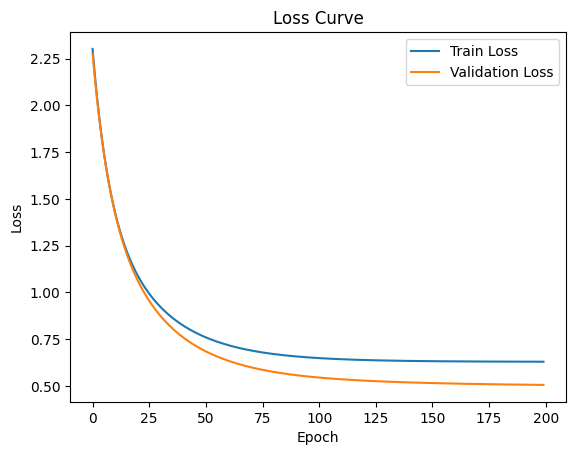

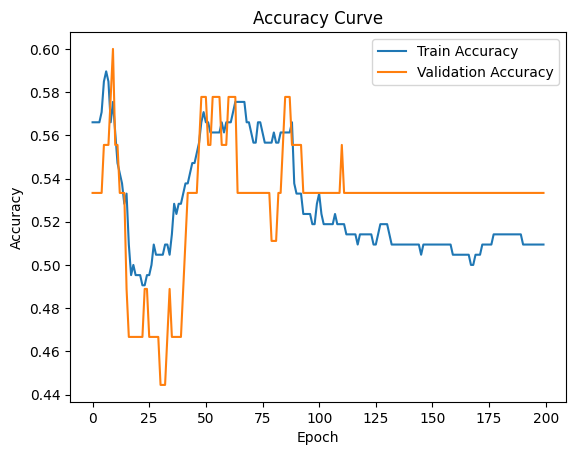

In [5]:
import matplotlib.pyplot as plt

# LOSS
plt.figure()
plt.plot(train_loss,label="Train Loss")
plt.plot(val_loss,label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# ACCURACY
plt.figure()
plt.plot(train_acc,label="Train Accuracy")
plt.plot(val_acc,label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()